# Shooting Incidents in NYC (2006 - 2025)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
shootings_df = pd.read_csv('../Cleaned_Data/Cleaned_Shootings_(2006-Present)_20260401.csv')
offenders_df = pd.read_csv('../Cleaned_Data/Cleaned_Shooting_Offenders_(2006-Present)_20260401.csv')
victims_df = pd.read_csv('../Cleaned_Data/Cleaned_Shooting_Victims_(2006-Present)_20260401.csv')
combined_df = pd.read_csv('../Cleaned_Data/Combined_Cleaned_Shooting_Incidents_(2006-Present)_20260401.csv')
laws_df = pd.read_csv('../Data/nyc_ny_gun_violence_laws_2006_2025_verified.csv')
policies_df = pd.read_csv('../Data/nyc_violence_policies_2006_2025.csv')

In [25]:
combined_df['STAT_MURDER_FLG'] = (combined_df['STAT_MURDER_FLG'] == 'Y').astype(int)
combined_df['OCCUR_DATETIME'] = pd.to_datetime(combined_df['OCCUR_DATETIME'])
laws_df['date_signed'] = pd.to_datetime(laws_df['date_signed'])
policies_df['date_implemented'] = pd.to_datetime(policies_df['date_implemented'])

## Shooting Incidents and Murders Over Time

In [26]:
year_group = combined_df.groupby(combined_df['OCCUR_DATETIME'].dt.year)['STAT_MURDER_FLG']
year_count = year_group.count()
year_sum = year_group.sum()

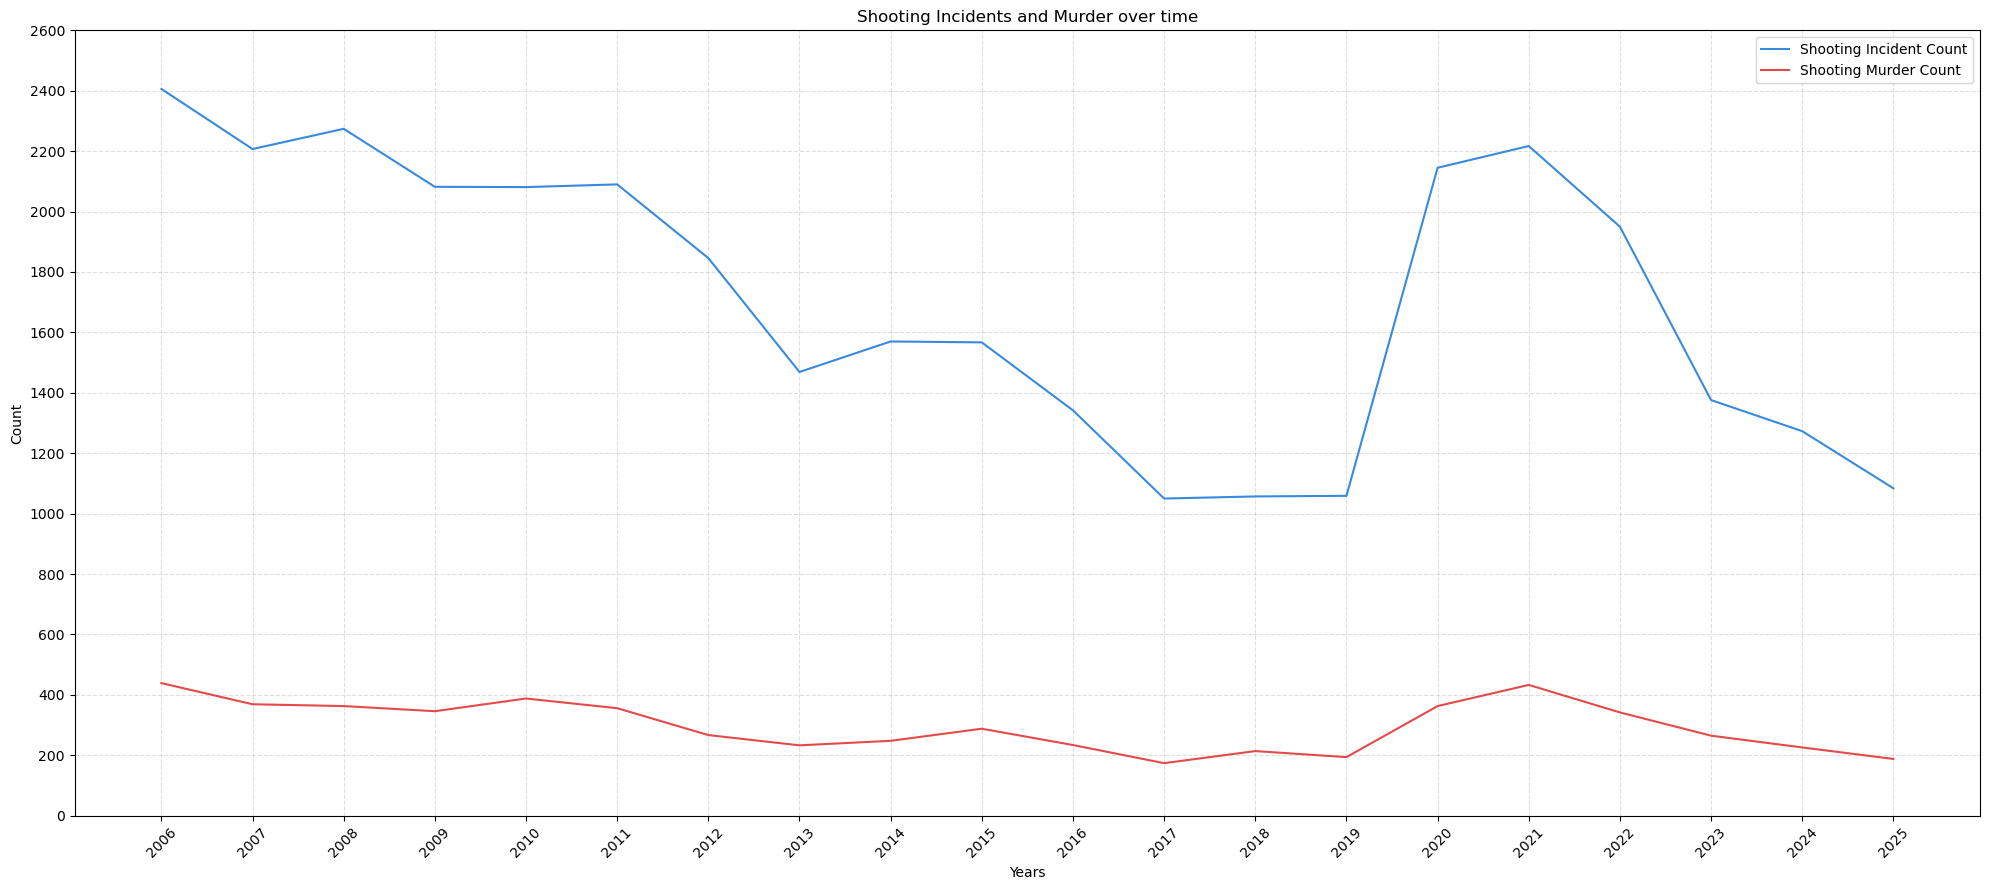

In [33]:
fig,ax = plt.subplots(figsize=(20,9))

ax.plot(range(len(year_count.values)), year_count.values, c='#378ADD', label='Shooting Incident Count')
ax.plot(range(len(year_sum.values)), year_sum.values, c='#E24B4A', label='Shooting Murder Count')

ax.set_xticks(range(len(year_sum.values)))
ax.set_xticklabels([int(x) for x in year_sum.index], rotation=45)
ax.set_yticks(range(0,2800,200))

ax.grid(axis='both', linestyle='--', alpha=0.4)

ax.set_title('Shooting Incidents and Murder over time')
ax.set_xlabel('Years')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

### The decline (2006-2019)

Shootings fell from **~2,400 to ~1,050** - a ~56% drop. The laws and policies driving this weren't working in isolation; they layered on top of each other:

- **2006** - *NY Penal Law Ch. 742 & 745* and *Ch. 320* stiffened penalties for criminal weapon possession and violent felony sentencing. The line begins its first modest dip here, though penalty-only laws historically show weak effect on their own.

- **2009** - **SNUG Street Outreach Program** launched, deploying trust-worthy messengers to interrupt conflicts before they escalate. The downward slope steepens noticeably, 2 years after this point.

- **2012** - **Cure Violence / CMS** introduced in Brooklyn alongside the *Private Sale Background Check Law*. NYC Council analysis found a 17% reduction at Cure Violence sites in year one, the steepest decline phase begins here.

- **2013** - The **NY SAFE Act** passed, the most comprehensive gun law in state history: universal background checks, assault weapon restrictions, magazine limits. The same year, *Floyd v. City of New York* ruled stop-and-frisk unconstitutional. Stops fell 98% by 2017, yet the blue line **kept falling**, showing CVI programs, not SQF, were doing the real work.

- **2014** - **GIVE Initiative** and **CMS citywide formalization** - John Jay researchers found a 28% reduction in shooting victimizations at CMS sites in the first 24 months. This is the one of the sharpest drops visible in the chart.

- **2019** - A wave of seven laws passed- the **Red Flag Law**, a **30-day background check extension**, a **bump stock ban**, and a **3D-printed gun ban**. Shootings hit their historic low of ~1,050 this year.


### The COVID rupture (2020-2021)

Both lines spike violently. The **COVID-19 pandemic** is logged in the policy dataset as a structural break - not a policy failure, but an exogenous shock. Courts closed, outreach workers couldn't operate, and economic stress surged. The **$35M CMS Emergency Expansion** in 2020 partially cushioned the blow, but couldn't prevent the overall surge to ~2,200 incidents by 2021.

### The recovery (2022-2025)

The fastest decline in the dataset. Three things drove it simultaneously:

- **2021-2022 ghost gun laws** - *Scott J. Beigel Unfinished Receiver Act*, *Jose Webster Untraceable Firearms Act*, and 2022 amendments removed untraceable weapons from the supply chain. The **Interstate Task Force on Illegal Guns** (est. 2022) seized 9,408 firearms in 2024 alone, including 769 ghost guns.

- **2022 legislative wave** - 11 laws in a single year:- the **Concealed Carry Improvement Act**, **large-capacity magazine grandfathering eliminated**, **enhanced ERPO mandatory reporting**, and **age restriction for semi-automatic rifles (21+)**. Supply and access tightened simultaneously.

- **2024 NYPD Summer Deployment Zones** - produced a 65% decline in shootings in targeted areas during deployment, directly contributing to 2025 hitting the one of the lowest incident counts in the 20-year record.

**Bottom line-** the laws and policies that moved the line were the ones that disrupted supply and funded community intervention not penalty enhancements alone. COVID proved how fast structural progress can unravel. The 2022–2025 recovery, is comparatively faster, as many of the laws and policies were already in-place. 

## Shooting Incidents Distribution by Month and Year

In [28]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_group = combined_df.groupby([combined_df['OCCUR_DATETIME'].dt.month, combined_df['OCCUR_DATETIME'].dt.year])['STAT_MURDER_FLG'].count().unstack()

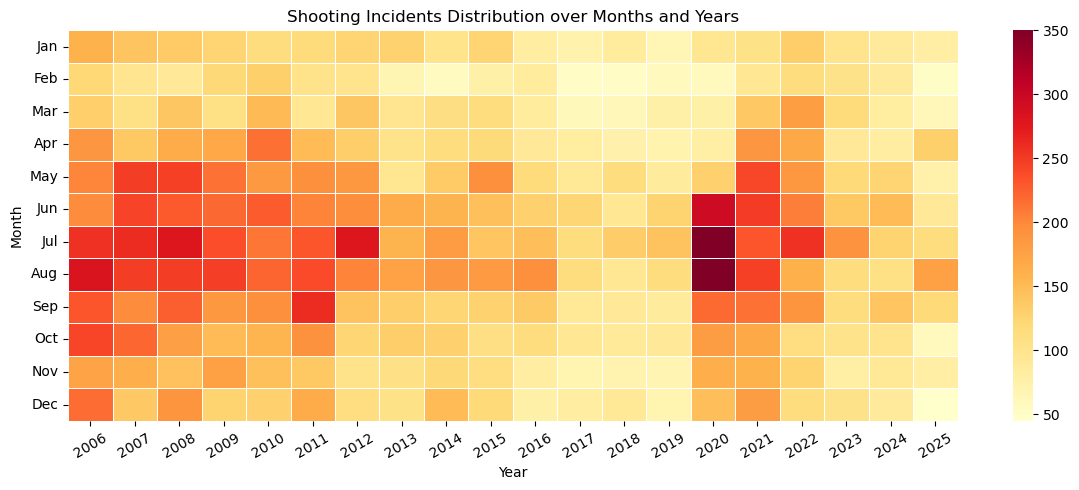

In [29]:
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(data=monthly_group, cmap='YlOrRd',linewidth=.5, ax=ax)
ax.set_xticklabels([int(x) for x in monthly_group.columns], rotation=30)
ax.set_yticklabels(month_names, rotation=360)
ax.set_title('Shooting Incidents Distribution over Months and Years')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

### Summer never changes
July and August are the darkest rows almost every single year, no law or policy has permanently stopped this trend. January through March sit at the opposite extreme, often half the count of peak summer months. Heat, outdoor activity, and school breaks appear to drive this more than anything on the books.

### Clear different eras
- **2006-2012** - deep reds dominate, especially the summer rows
- **2013-2019** - steady fade toward orange and yellow as CVI programs and laws (like SAFE ACT) took hold
- **2020-2021** - July and August of 2020 goes near-black, the highest monthly count in this 20 years of data, 7-8 years of progress erased in one summer
- **2022-2025** - gradual return toward pre-COVID levels, but not fully there yet

### The COVID signature
July 2020 is the darkest cell in the entire chart - darker than any month in 2006 or 2007. The surge hit exactly when violence peaked during covid, amplified by the simultaneous collapse of courts, outreach programs, social services and NYPD budget pullback.

In [30]:
loc_group = combined_df.groupby('LOC_CLASSFCTN_DESC')['STAT_MURDER_FLG'].agg([
    'count', 'mean'
]).sort_values('count',ascending=True)
loc_group['mean'] = loc_group['mean'] * 100

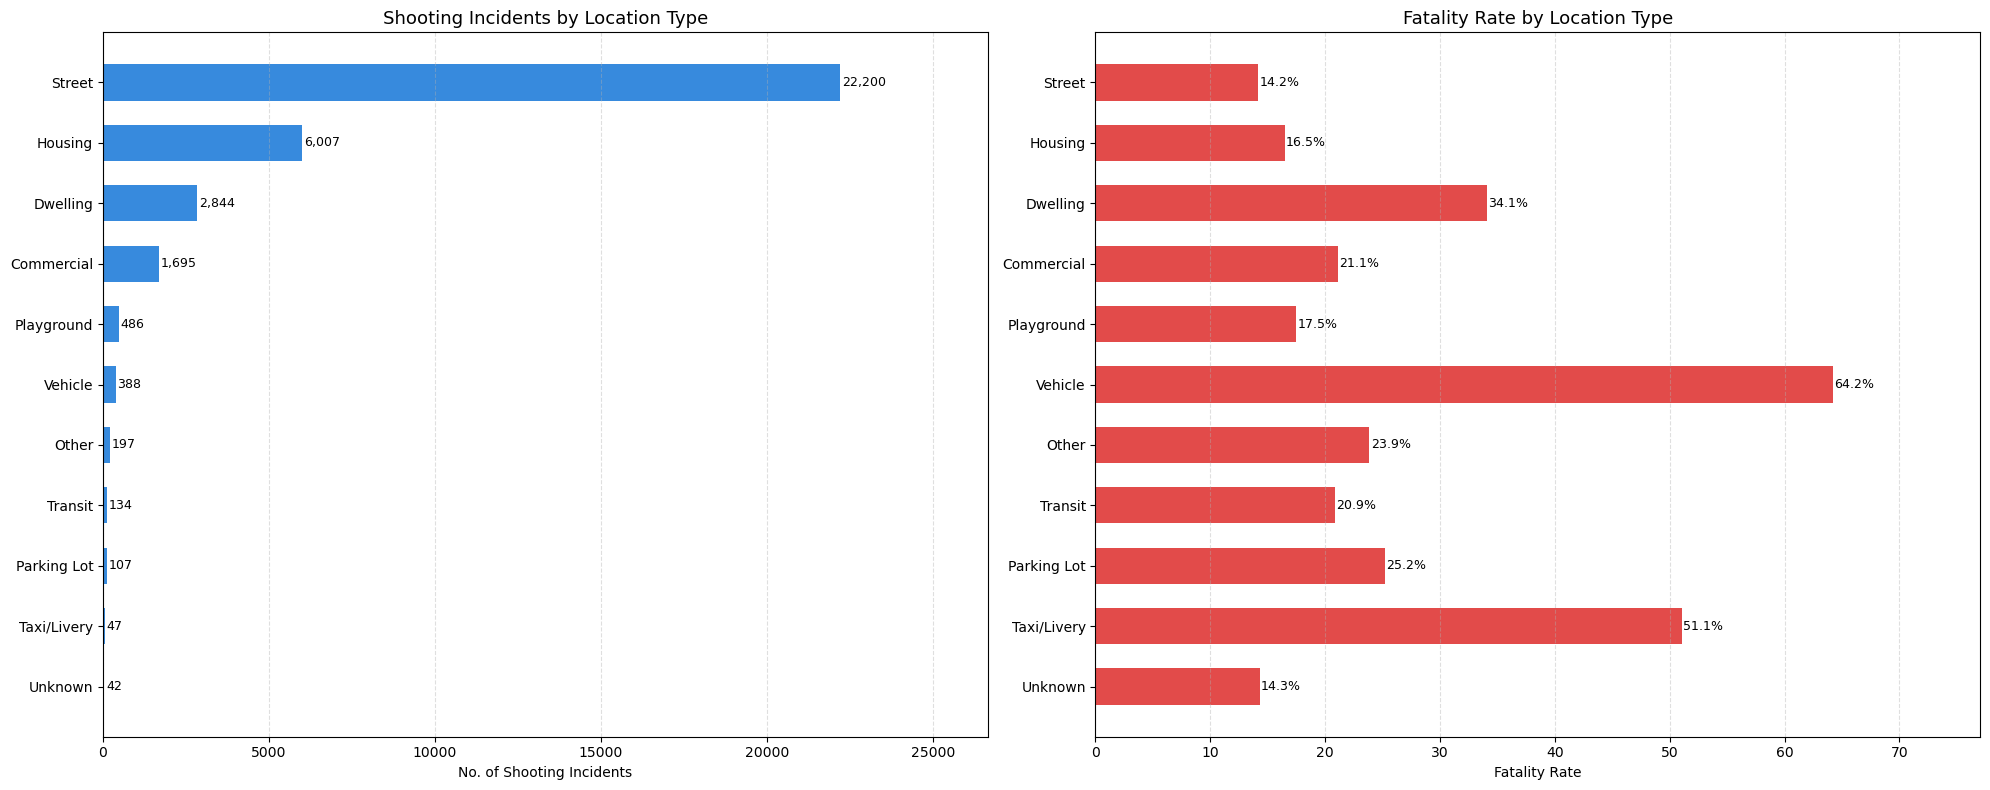

In [ ]:
fig, [left_ax, right_ax] = plt.subplots(1,2,figsize=(20,8))

left_ax.barh(loc_group.index, loc_group['count'], height=0.6, color='#378ADD')
right_ax.barh(loc_group.index, loc_group['mean'], height=0.6, color='#E24B4A')

for i,count in enumerate(loc_group['count']):
    left_ax.text(count+50, i, f'{count:,}', fontsize=9, va='center')

for i,count in enumerate(loc_group['mean']):
    right_ax.text(count+0.1, i, f'{count:.1f}%', fontsize=9, va='center')

left_ax.set_xlim(0,loc_group['count'].max()*1.2)
right_ax.set_xlim(0,loc_group['mean'].max()*1.2)

left_ax.grid(axis='x', alpha=0.4, linestyle='--')
right_ax.grid(axis='x', alpha=0.4, linestyle='--')

left_ax.set_title('Shooting Incidents by Location Type',fontsize=13)
right_ax.set_title('Fatality Rate by Location Type',fontsize=13)

left_ax.set_xlabel('No. of Shooting Incidents')
right_ax.set_xlabel('Fatality Rate')

plt.tight_layout()
plt.show()

### Volume: streets dominate
Most shootings (22,200) happen on the street but streets have the **lowest fatality rate at 14.2%**. Most street shootings are survivable, driven by escalated conflicts and stray bullets rather than intent to kill.

### Lethality- vehicles and taxis stand out
- **Vehicle - 64.2%** | **Taxi/Livery - 51.1%** | **Dwelling - 34.1%**

These locations share a common thread- the victim is isolated, the setting is controlled by the perpetrator, and the shooting is typically premeditated. Vehicle and taxi shootings are largely execution-style, no escape route, no bystander intervention. Dwellings follow the same logic, frequently involving domestic violence or targeted home invasions.

### What this means
Street-based programs (Cure Violence, Summer Zones) correctly target volume but are irrelevant to vehicle and taxi shootings, which require intelligence-led disruption of planned violence, not conflict mediation.

**Where violence is common and where it is deadly are almost opposite answers.**